# 🔮 Customer Churn Prediction — End-to-End Data Science Project

**Author:** Data Science Team
**Goal:** Predict whether a customer will churn (leave the company), identify the key
drivers of churn, and turn those insights into concrete retention actions.

---

## 1. Business Problem

Customer churn — the rate at which customers stop doing business with a company — is one
of the most expensive problems in subscription and service businesses. Acquiring a new
customer typically costs **5–25x more** than retaining an existing one, so even a small
reduction in churn has an outsized impact on revenue and lifetime value (LTV).

**Business questions this project answers:**
1. Which customers are at the highest risk of churning *right now*?
2. What are the strongest behavioral and contractual drivers of churn?
3. Can we build a model accurate and explainable enough to act on?
4. What specific retention actions should the business take, and for whom?

**Success criteria:** A model with strong recall on the churn class (catching at-risk
customers matters more than perfect precision, since the cost of a missed churner is
usually higher than the cost of a retention offer to a happy customer) and a clear,
prioritized set of business recommendations.


---
## 2. Data Collection & Understanding

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
pio.templates.default = "plotly_white"

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load dataset
df = pd.read_csv('../data/customer_churn.csv')
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 7058 rows x 23 columns


,CustomerID,Gender,SeniorCitizen,Age,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,CustomerSupportCalls,Churn
0,CUST-13308,Female,0,44,Yes,No,11,Yes,No,DSL,...,Yes,Yes,No,One Year,Yes,Mailed Check,60.58,631.25,3,No
1,CUST-15939,Female,0,39,No,No,26,Yes,No,DSL,...,No,No,No,Two Year,No,Mailed Check,46.22,1159.56,4,No
2,CUST-11410,Female,1,67,No,No,33,Yes,Yes,DSL,...,Yes,No,No,Month-to-Month,Yes,Bank Transfer,70.89,2277.25,2,No
3,CUST-13458,Male,0,55,Yes,No,15,Yes,Yes,DSL,...,No,Yes,Yes,Two Year,Yes,Mailed Check,73.96,1069.47,2,Yes
4,CUST-13194,Female,0,36,Yes,Yes,25,Yes,Yes,DSL,...,No,Yes,Yes,Month-to-Month,No,Mailed Check,77.89,1927.69,3,No


In [3]:
# Structural overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7058 entries, 0 to 7057
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            7058 non-null   str    
 1   Gender                7058 non-null   str    
 2   SeniorCitizen         7058 non-null   int64  
 3   Age                   7058 non-null   int64  
 4   Partner               7058 non-null   str    
 5   Dependents            7058 non-null   str    
 6   Tenure                7058 non-null   int64  
 7   PhoneService          7058 non-null   str    
 8   MultipleLines         7058 non-null   str    
 9   InternetService       7058 non-null   str    
 10  OnlineSecurity        7058 non-null   str    
 11  OnlineBackup          7058 non-null   str    
 12  DeviceProtection      7058 non-null   str    
 13  TechSupport           7058 non-null   str    
 14  StreamingTV           7058 non-null   str    
 15  StreamingMovies       7058 non-n

In [4]:
# Statistical summary of numeric columns
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7058.0,0.155285,0.362202,0.0,0.000,0.000,0.00,1.00
Age,7058.0,46.279683,17.632656,18.0,31.000,46.000,59.00,84.00
Tenure,7058.0,33.447294,20.579589,0.0,17.000,29.000,48.00,72.00
MonthlyCharges,7058.0,61.874158,24.580652,18.0,47.895,67.075,80.68,120.12
CustomerSupportCalls,7058.0,2.504959,1.728584,0.0,1.000,2.000,4.00,12.00


In [5]:
# Statistical summary of categorical columns
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7058,7043,CUST-10132,2
Gender,7058,2,Male,3617
Partner,7058,2,No,3661
Dependents,7058,2,No,4900
PhoneService,7058,2,Yes,6358
MultipleLines,7058,3,No,3756
InternetService,7058,3,Fiber Optic,3122
OnlineSecurity,7058,3,No,3545
OnlineBackup,7058,3,No,3327
DeviceProtection,7058,3,No,3319


### Target Variable: Churn Distribution

Before anything else, we look at how imbalanced the target is — this determines our
evaluation strategy (accuracy alone would be misleading) and whether we need to handle
class imbalance during modeling.

Churn counts:


 Churn
No     4641
Yes    2417
Name: count, dtype: int64

Churn percentage:
 Churn
No     65.76
Yes    34.24
Name: proportion, dtype: float64


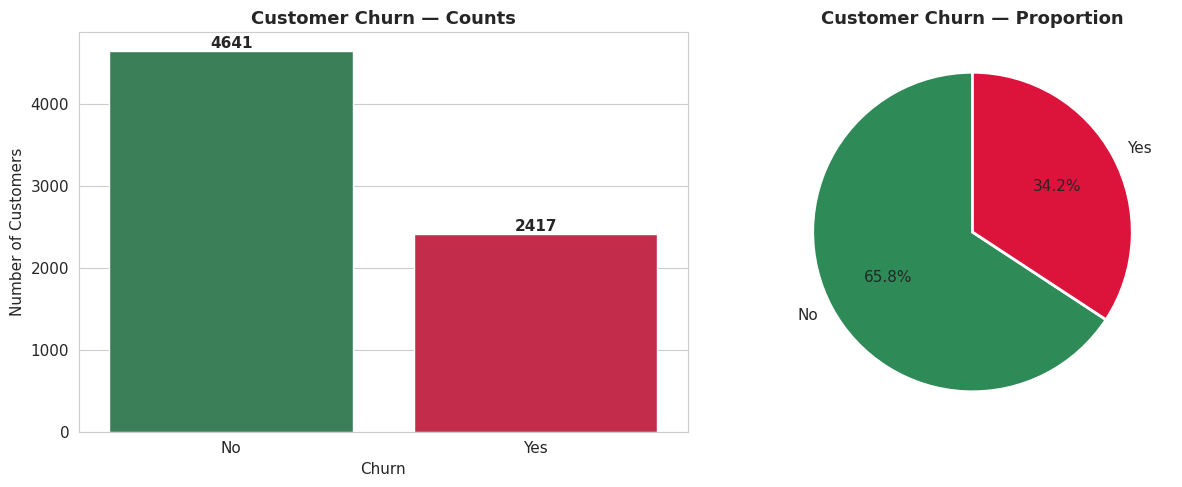


Class imbalance ratio (No:Yes) ≈ 1.92 : 1
Moderate imbalance — we'll use stratified splits and rely on Precision/Recall/F1/ROC-AUC, not Accuracy alone.


In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:\n", churn_counts)
print("\nChurn percentage:\n", churn_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2E8B57', '#DC143C'],
              order=['No', 'Yes'], legend=False, ax=axes[0])
axes[0].set_title('Customer Churn — Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontweight='bold')

axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct='%1.1f%%',
            colors=['#2E8B57', '#DC143C'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Customer Churn — Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio (No:Yes) ≈ {churn_counts['No']/churn_counts['Yes']:.2f} : 1")
print("Moderate imbalance — we'll use stratified splits and rely on Precision/Recall/F1/ROC-AUC, not Accuracy alone.")

---
## 3. Data Cleaning & Preprocessing

In [7]:
# 3.1 Check for duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 15
Shape after removing duplicates: (7043, 23)


In [8]:
# 3.2 Handle the TotalCharges column — it was loaded as text because of blank/whitespace entries
print("TotalCharges dtype before cleaning:", df['TotalCharges'].dtype)

# Convert blanks/whitespace to NaN, then cast to numeric
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())
print("TotalCharges dtype after cleaning:", df['TotalCharges'].dtype)

TotalCharges dtype before cleaning: str
Missing values in TotalCharges: 112
TotalCharges dtype after cleaning: float64


In [9]:
# 3.3 Full missing-value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_report

,Missing Count,Missing %
TotalCharges,112,1.59


In [10]:
# 3.4 Impute missing TotalCharges
# Customers with 0 tenure naturally have ~0 total charges; for everyone else,
# impute using MonthlyCharges * Tenure as a sensible, leakage-free estimate.
mask = df['TotalCharges'].isnull()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'Tenure']
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Remaining missing values: {df.isnull().sum().sum()}")

Remaining missing values: 0


In [11]:
# 3.5 Drop identifier column (not predictive) but keep a copy for the dashboard lookups
customer_ids = df['CustomerID'].copy()
df_model = df.drop(columns=['CustomerID'])
print("Columns retained for modeling:", list(df_model.columns))

Columns retained for modeling: ['Gender', 'SeniorCitizen', 'Age', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'CustomerSupportCalls', 'Churn']


In [12]:
# 3.6 Outlier detection (IQR method) on key numeric columns
numeric_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'CustomerSupportCalls']

def iqr_outlier_report(data, cols):
    report = []
    for col in cols:
        Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((data[col] < lower) | (data[col] > upper)).sum()
        report.append([col, round(lower,2), round(upper,2), n_out, round(100*n_out/len(data),2)])
    return pd.DataFrame(report, columns=['Column', 'Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier %'])

outlier_report = iqr_outlier_report(df_model, numeric_cols)
outlier_report

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Age,-11.00,101.00,0,0.00
1,Tenure,-29.50,94.50,0,0.00
2,MonthlyCharges,-1.22,129.84,0,0.00
3,TotalCharges,-2478.32,6179.82,92,1.31
4,CustomerSupportCalls,-3.50,8.50,16,0.23


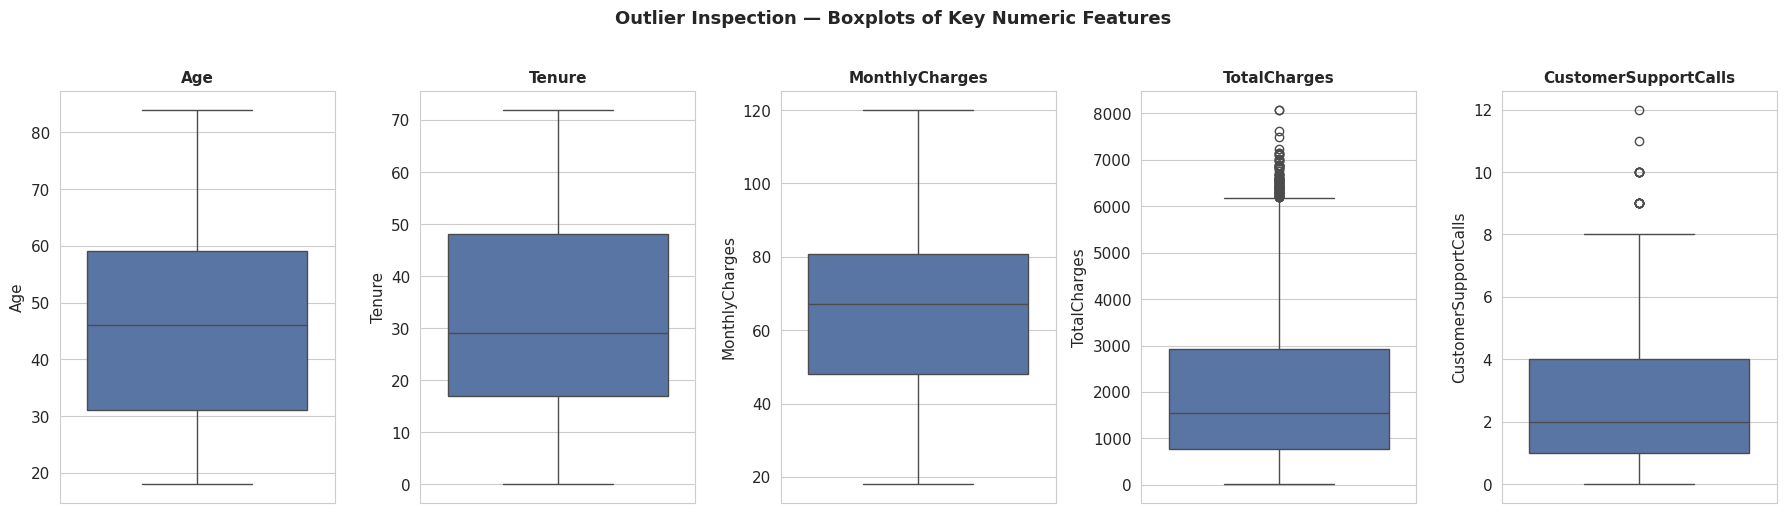

In [13]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_model[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=11, fontweight='bold')
plt.suptitle('Outlier Inspection — Boxplots of Key Numeric Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/02_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Treatment: cap extreme CustomerSupportCalls at the 99th percentile (genuine but rare extreme values);
# leave charges/tenure untouched since their "outliers" are legitimate high-value long-tenure customers,
# not data errors — capping them would destroy real signal the model needs.
cap_value = df_model['CustomerSupportCalls'].quantile(0.99)
n_capped = (df_model['CustomerSupportCalls'] > cap_value).sum()
df_model['CustomerSupportCalls'] = np.where(
    df_model['CustomerSupportCalls'] > cap_value, cap_value, df_model['CustomerSupportCalls']
)
print(f"Capped {n_capped} extreme CustomerSupportCalls values at the 99th percentile ({cap_value:.0f} calls).")

Capped 58 extreme CustomerSupportCalls values at the 99th percentile (7 calls).


In [15]:
# 3.7 Encode the target variable
df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Yes': 1})
df_model['Churn'].value_counts()

Churn
0    4631
1    2412
Name: count, dtype: int64

In [16]:
# 3.8 Encode categorical features
# Binary Yes/No-style columns -> label encode 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

df_model['Gender'] = df_model['Gender'].map({'Male': 1, 'Female': 0})

# Multi-category columns -> one-hot encode
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df_encoded = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape after encoding: (7043, 33)


,Gender,SeniorCitizen,Age,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No Internet Service,StreamingTV_Yes,StreamingMovies_No Internet Service,StreamingMovies_Yes,Contract_One Year,Contract_Two Year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaymentMethod_Mailed Check
0,0,0,44,1,0,11,1,1,60.58,631.25,...,True,False,True,False,False,True,False,False,False,True
1,0,0,39,0,0,26,1,0,46.22,1159.56,...,False,False,False,False,False,False,True,False,False,True
2,0,1,67,0,0,33,1,1,70.89,2277.25,...,True,False,False,False,False,False,False,False,False,False
3,1,0,55,1,0,15,1,1,73.96,1069.47,...,False,False,True,False,True,False,True,False,False,True
4,0,0,36,1,1,25,1,0,77.89,1927.69,...,False,False,True,False,True,False,False,False,False,True


---
## 4. Exploratory Data Analysis (EDA)

We now explore relationships between features and churn using the **cleaned but
not-yet-encoded** dataframe (`df_model`), since human-readable category labels make
charts far easier to interpret than one-hot columns.

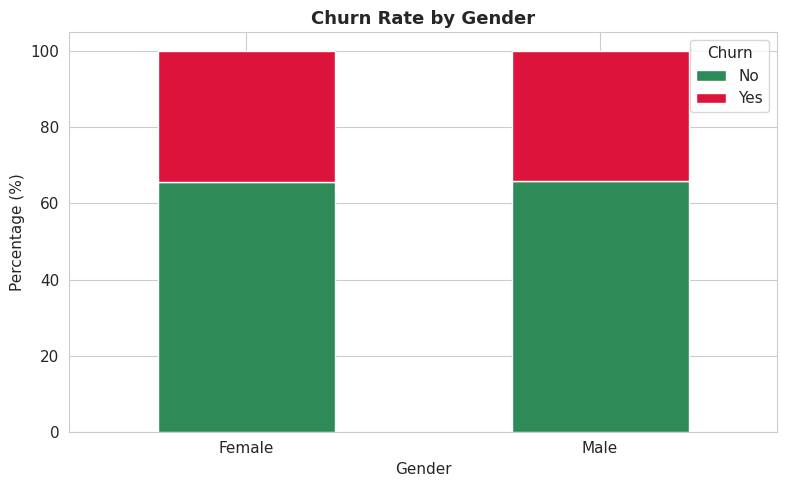

Gender shows only a marginal relationship with churn — confirming it's rarely a strong driver in telecom churn.


In [17]:
# 4.1 Gender vs Churn
fig, ax = plt.subplots(figsize=(8, 5))
gender_churn = pd.crosstab(df_model['Gender'].map({1:'Male', 0:'Female'}), df['Churn'].iloc[df_model.index].values, normalize='index') * 100
gender_churn.columns = ['No', 'Yes'] if list(gender_churn.columns) == [0,1] else gender_churn.columns
gender_churn.plot(kind='bar', stacked=True, color=['#2E8B57', '#DC143C'], ax=ax)
ax.set_title('Churn Rate by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Gender')
ax.legend(title='Churn', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/03_gender_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gender shows only a marginal relationship with churn — confirming it's rarely a strong driver in telecom churn.")

In [18]:
# 4.2 Contract Type vs Churn (typically one of the strongest predictors)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

fig = px.bar(
    contract_churn.reset_index().melt(id_vars='Contract', var_name='Churn', value_name='Percentage'),
    x='Contract', y='Percentage', color='Churn', barmode='group',
    color_discrete_map={'No': '#2E8B57', 'Yes': '#DC143C'},
    title='Churn Rate by Contract Type', text_auto='.1f'
)
fig.update_layout(yaxis_title='Percentage of Customers (%)', title_x=0.5)
fig.write_image('../images/04_contract_vs_churn.png', scale=2)
fig.show()

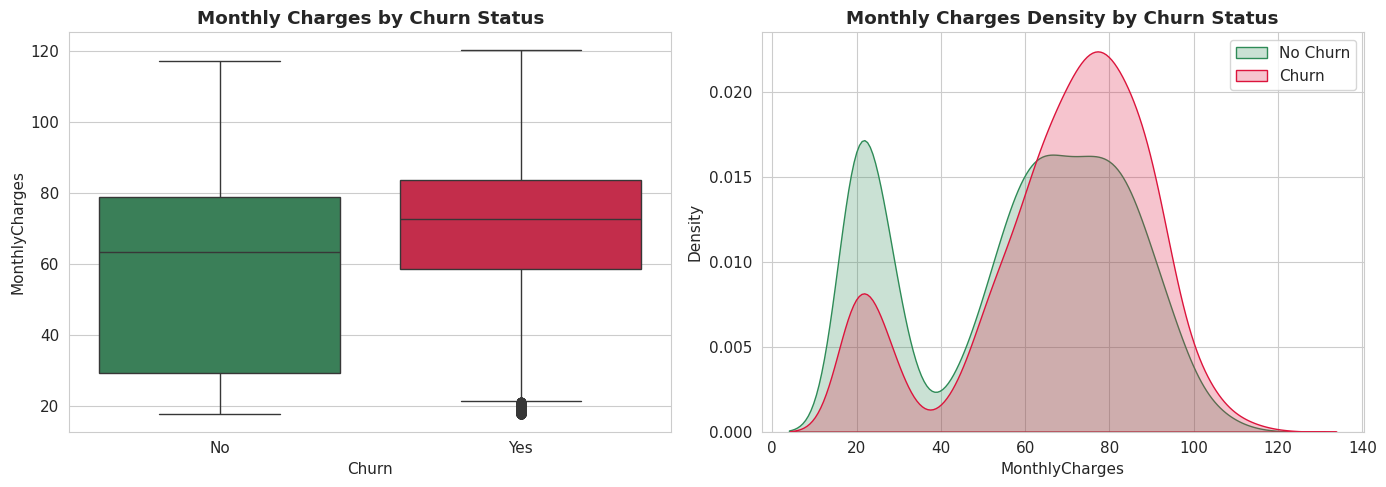

Churn
No     58.59
Yes    68.23
Name: MonthlyCharges, dtype: float64


In [19]:
# 4.3 Monthly Charges vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', order=['No','Yes'],
            palette=['#2E8B57', '#DC143C'], legend=False, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn Status', fontweight='bold')

sns.kdeplot(data=df[df['Churn']=='No'], x='MonthlyCharges', fill=True, color='#2E8B57', label='No Churn', ax=axes[1])
sns.kdeplot(data=df[df['Churn']=='Yes'], x='MonthlyCharges', fill=True, color='#DC143C', label='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges Density by Churn Status', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/05_monthlycharges_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

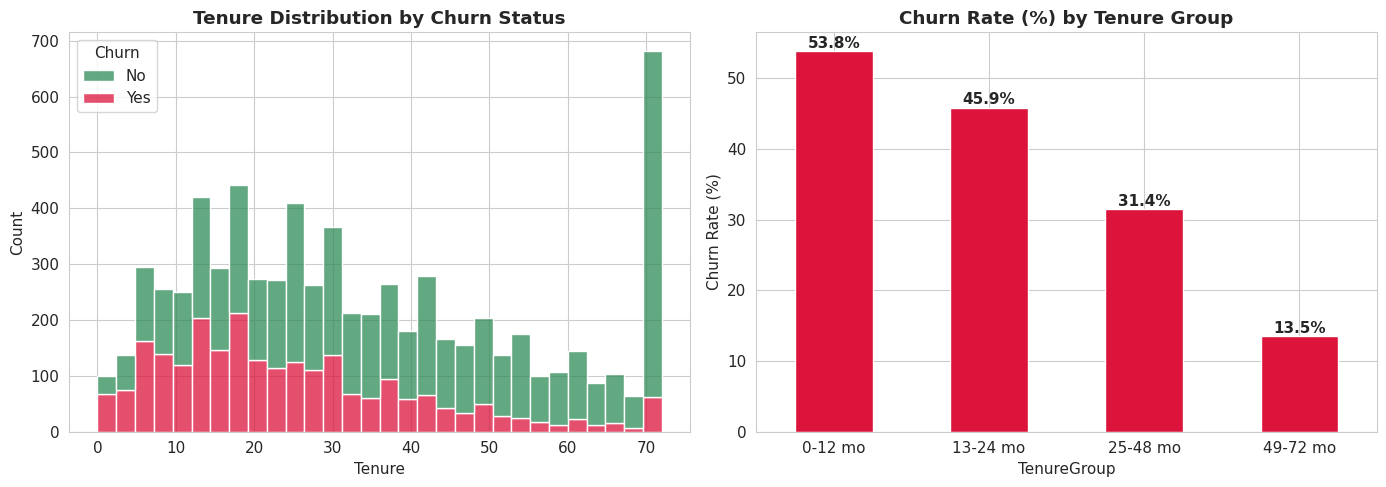

Clear pattern: churn risk is heavily concentrated in the first 12 months of the customer lifecycle.


In [20]:
# 4.4 Tenure Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack', bins=30,
             palette=['#2E8B57', '#DC143C'], ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status', fontweight='bold')

# Bucket tenure into business-friendly groups
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']
df['TenureGroup'] = pd.cut(df['Tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)
tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index')['Yes'] * 100
tenure_churn.plot(kind='bar', color='#DC143C', ax=axes[1])
axes[1].set_title('Churn Rate (%) by Tenure Group', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../images/06_tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Clear pattern: churn risk is heavily concentrated in the first 12 months of the customer lifecycle.")

In [21]:
# 4.5 Payment Method Analysis
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')['Yes'].sort_values(ascending=False) * 100

fig = px.bar(
    payment_churn.reset_index().rename(columns={'Yes':'ChurnRate'}),
    x='PaymentMethod', y='ChurnRate', color='ChurnRate', color_continuous_scale='Reds',
    title='Churn Rate (%) by Payment Method', text_auto='.1f'
)
fig.update_layout(yaxis_title='Churn Rate (%)', title_x=0.5, showlegend=False)
fig.write_image('../images/07_payment_method_vs_churn.png', scale=2)
fig.show()

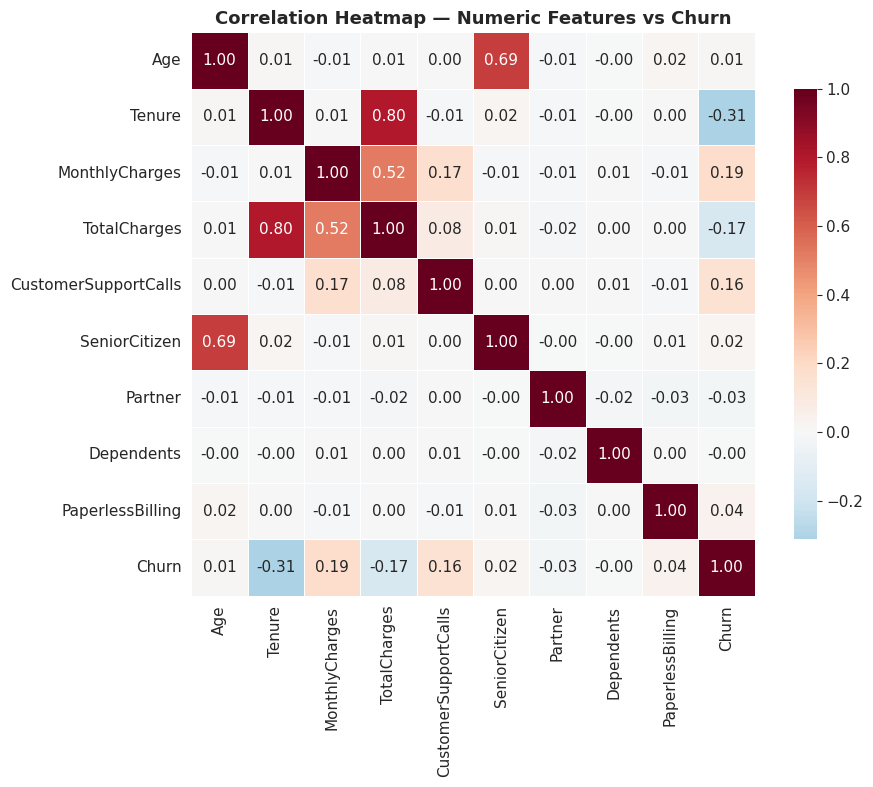

Churn correlations (sorted):
Churn                   1.000000
MonthlyCharges          0.186127
CustomerSupportCalls    0.156352
PaperlessBilling        0.044006
SeniorCitizen           0.022827
Age                     0.011289
Dependents             -0.004747
Partner                -0.028125
TotalCharges           -0.166197
Tenure                 -0.312781
Name: Churn, dtype: float64


In [22]:
# 4.6 Correlation Heatmap (numeric + encoded binary features)
corr_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'CustomerSupportCalls',
             'SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling']
corr_df = df_model[corr_cols + ['Churn']].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Churn correlations (sorted):")
print(corr_matrix['Churn'].sort_values(ascending=False))

In [23]:
# 4.7 Customer Segmentation Analysis — simple value/risk segments via KMeans on scaled features
from sklearn.cluster import KMeans

seg_features = df_model[['Tenure', 'MonthlyCharges', 'CustomerSupportCalls']].copy()
seg_scaler = StandardScaler()
seg_scaled = seg_scaler.fit_transform(seg_features)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df_model['Segment'] = kmeans.fit_predict(seg_scaled)

segment_profile = df_model.groupby('Segment').agg(
    Avg_Tenure=('Tenure', 'mean'),
    Avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Avg_SupportCalls=('CustomerSupportCalls', 'mean'),
    Churn_Rate=('Churn', 'mean'),
    Count=('Churn', 'size')
).round(2)
segment_profile['Churn_Rate'] = (segment_profile['Churn_Rate'] * 100).round(1)
segment_profile = segment_profile.sort_values('Churn_Rate', ascending=False)
segment_profile

,Avg_Tenure,Avg_MonthlyCharges,Avg_SupportCalls,Churn_Rate,Count
Segment,,,,,
2,27.40,73.75,4.99,52.0,1357
3,20.28,72.41,1.68,45.0,2486
1,33.39,24.23,1.92,20.0,1605
0,59.12,73.30,2.20,17.0,1595


In [24]:
# Label segments based on their profile for business readability
segment_names = {}
for seg_id, row in segment_profile.iterrows():
    if row['Churn_Rate'] > 40:
        name = 'High-Risk New Customers' if row['Avg_Tenure'] < 20 else 'High-Risk High-Spenders'
    elif row['Churn_Rate'] > 25:
        name = 'At-Risk Customers'
    else:
        name = 'Loyal Long-Tenure Customers'
    segment_names[seg_id] = name

df_model['SegmentName'] = df_model['Segment'].map(segment_names)
segment_profile['SegmentName'] = [segment_names[i] for i in segment_profile.index]

fig = px.scatter(
    df_model, x='Tenure', y='MonthlyCharges', color='SegmentName',
    size='CustomerSupportCalls', opacity=0.6,
    title='Customer Segments: Tenure vs Monthly Charges',
    labels={'Tenure':'Tenure (months)', 'MonthlyCharges':'Monthly Charges ($)'}
)
fig.update_layout(title_x=0.5)
fig.write_image('../images/09_customer_segmentation.png', scale=2)
fig.show()

segment_profile[['SegmentName', 'Avg_Tenure', 'Avg_MonthlyCharges', 'Avg_SupportCalls', 'Churn_Rate', 'Count']]

,SegmentName,Avg_Tenure,Avg_MonthlyCharges,Avg_SupportCalls,Churn_Rate,Count
Segment,,,,,,
2,High-Risk High-Spenders,27.40,73.75,4.99,52.0,1357
3,High-Risk High-Spenders,20.28,72.41,1.68,45.0,2486
1,Loyal Long-Tenure Customers,33.39,24.23,1.92,20.0,1605
0,Loyal Long-Tenure Customers,59.12,73.30,2.20,17.0,1595


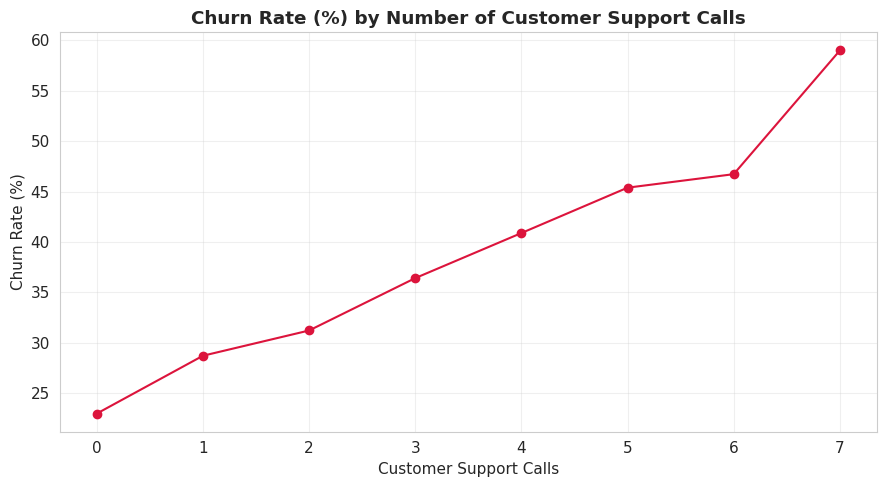

Churn rate rises sharply once a customer places 4+ support calls — a strong early-warning signal.


In [25]:
# 4.8 Customer Support Calls vs Churn
fig, ax = plt.subplots(figsize=(9, 5))
support_churn = df.assign(CustomerSupportCalls=df_model['CustomerSupportCalls']).groupby('CustomerSupportCalls')['Churn'].apply(lambda x: (x=='Yes').mean()*100)
support_churn.plot(kind='line', marker='o', color='#DC143C', ax=ax)
ax.set_title('Churn Rate (%) by Number of Customer Support Calls', fontweight='bold')
ax.set_xlabel('Customer Support Calls')
ax.set_ylabel('Churn Rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/10_support_calls_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Churn rate rises sharply once a customer places 4+ support calls — a strong early-warning signal.")

### Top Factors Influencing Churn (from EDA)

Based on the analysis above, the strongest churn signals are:

1. **Contract type** — Month-to-month customers churn far more than 1-/2-year contract holders
2. **Tenure** — Risk is concentrated in the first 12 months
3. **Customer support calls** — 4+ calls is a strong early-warning signal
4. **Internet service / Monthly charges** — Fiber-optic and higher-bill customers churn more
5. **Payment method** — Electronic check users churn more than automatic-payment users
6. **Lack of add-on services** — No online security / no tech support correlates with higher churn

We confirm these statistically in Section 6 (Feature Importance) once models are trained.

---
## 5. Feature Engineering

In [26]:
# 5.1 Create new, business-meaningful features
df_fe = df_model.drop(columns=['Segment', 'SegmentName']).copy()

# Average revenue per month of tenure (captures spending intensity independent of how long they've stayed)
df_fe['AvgChargePerTenure'] = df_fe['TotalCharges'] / df_fe['Tenure'].replace(0, 1)

# Flag for brand-new customers (highest risk window identified in EDA)
df_fe['IsNewCustomer'] = (df_fe['Tenure'] <= 6).astype(int)

# Flag for high support-call volume (early warning signal identified in EDA)
df_fe['HighSupportCalls'] = (df_fe['CustomerSupportCalls'] >= 4).astype(int)

# Count of "add-on" services subscribed (engagement / stickiness proxy)
addon_yes_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_fe['TotalAddonServices'] = (df_fe[addon_yes_cols] == 'Yes').sum(axis=1)

# Monthly charge relative to internet service tier average (is this customer overpaying for their tier?)
tier_avg = df_fe.groupby('InternetService')['MonthlyCharges'].transform('mean')
df_fe['ChargeVsTierAvg'] = df_fe['MonthlyCharges'] - tier_avg

# Contract risk flag (month-to-month = highest churn risk per EDA)
df_fe['IsMonthToMonth'] = (df_fe['Contract'] == 'Month-to-Month').astype(int)

print("New engineered features added:")
print(['AvgChargePerTenure', 'IsNewCustomer', 'HighSupportCalls', 'TotalAddonServices', 'ChargeVsTierAvg', 'IsMonthToMonth'])
df_fe[['AvgChargePerTenure', 'IsNewCustomer', 'HighSupportCalls', 'TotalAddonServices', 'ChargeVsTierAvg', 'IsMonthToMonth']].head()

New engineered features added:
['AvgChargePerTenure', 'IsNewCustomer', 'HighSupportCalls', 'TotalAddonServices', 'ChargeVsTierAvg', 'IsMonthToMonth']


,AvgChargePerTenure,IsNewCustomer,HighSupportCalls,TotalAddonServices,ChargeVsTierAvg,IsMonthToMonth
0,57.386364,0,0,4,-0.723533,0
1,44.598462,0,1,0,-15.083533,0
2,69.007576,0,0,3,9.586467,1
3,71.298000,0,0,3,12.656467,0
4,77.107600,0,0,4,16.586467,1


In [27]:
# 5.2 Encode remaining categorical columns (one-hot) for modeling
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df_final = pd.get_dummies(df_fe, columns=multi_cat_cols, drop_first=True)

# Make sure all feature columns are numeric
bool_cols = df_final.select_dtypes(include='bool').columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

print(f"Final modeling dataset shape: {df_final.shape}")
df_final.head()

Final modeling dataset shape: (7043, 39)


,Gender,SeniorCitizen,Age,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No Internet Service,StreamingTV_Yes,StreamingMovies_No Internet Service,StreamingMovies_Yes,Contract_One Year,Contract_Two Year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaymentMethod_Mailed Check
0,0,0,44,1,0,11,1,1,60.58,631.25,...,1,0,1,0,0,1,0,0,0,1
1,0,0,39,0,0,26,1,0,46.22,1159.56,...,0,0,0,0,0,0,1,0,0,1
2,0,1,67,0,0,33,1,1,70.89,2277.25,...,1,0,0,0,0,0,0,0,0,0
3,1,0,55,1,0,15,1,1,73.96,1069.47,...,0,0,1,0,1,0,1,0,0,1
4,0,0,36,1,1,25,1,0,77.89,1927.69,...,0,0,1,0,1,0,0,0,0,1


In [28]:
# 5.3 Feature selection — drop near-zero-variance / redundant columns, separate X and y
y = df_final['Churn']
X = df_final.drop(columns=['Churn'])

print(f"Feature matrix: {X.shape}, Target vector: {y.shape}")
print(f"Final feature list ({len(X.columns)} features):")
print(list(X.columns))

Feature matrix: (7043, 38), Target vector: (7043,)
Final feature list (38 features):
['Gender', 'SeniorCitizen', 'Age', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'CustomerSupportCalls', 'AvgChargePerTenure', 'IsNewCustomer', 'HighSupportCalls', 'TotalAddonServices', 'ChargeVsTierAvg', 'IsMonthToMonth', 'MultipleLines_No Phone Service', 'MultipleLines_Yes', 'InternetService_Fiber Optic', 'InternetService_No', 'OnlineSecurity_No Internet Service', 'OnlineSecurity_Yes', 'OnlineBackup_No Internet Service', 'OnlineBackup_Yes', 'DeviceProtection_No Internet Service', 'DeviceProtection_Yes', 'TechSupport_No Internet Service', 'TechSupport_Yes', 'StreamingTV_No Internet Service', 'StreamingTV_Yes', 'StreamingMovies_No Internet Service', 'StreamingMovies_Yes', 'Contract_One Year', 'Contract_Two Year', 'PaymentMethod_Credit Card', 'PaymentMethod_Electronic Check', 'PaymentMethod_Mailed Check']


In [29]:
# 5.4 Train-test split (stratified to preserve churn ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train set: {X_train.shape}, Churn rate: {y_train.mean():.3f}")
print(f"Test set:  {X_test.shape}, Churn rate: {y_test.mean():.3f}")

Train set: (5634, 38), Churn rate: 0.342
Test set:  (1409, 38), Churn rate: 0.343


In [30]:
# 5.5 Feature scaling (for distance/gradient-based models: Logistic Regression, SVM)
numeric_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'CustomerSupportCalls',
                     'AvgChargePerTenure', 'TotalAddonServices', 'ChargeVsTierAvg']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Scaling complete. Tree-based models will use unscaled X_train/X_test;")
print("Logistic Regression and SVM will use X_train_scaled/X_test_scaled.")

Scaling complete. Tree-based models will use unscaled X_train/X_test;
Logistic Regression and SVM will use X_train_scaled/X_test_scaled.


---
## 6. Machine Learning Models

We train five classifiers spanning linear, tree-based, ensemble, gradient-boosted, and
margin-based approaches, then compare them on the same held-out test set.

In [31]:
results = {}
trained_models = {}

def evaluate_model(name, model, X_te, y_te, y_pred, y_proba):
    results[name] = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1 Score': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba)
    }
    trained_models[name] = model
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))

In [32]:
# 6.1 Logistic Regression (baseline, highly interpretable)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test, y_pred, y_proba)


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.70      0.76       926
       Churn       0.56      0.74      0.64       483

    accuracy                           0.71      1409
   macro avg       0.70      0.72      0.70      1409
weighted avg       0.74      0.71      0.72      1409



In [33]:
# 6.2 Decision Tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, class_weight='balanced', random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]
evaluate_model('Decision Tree', dt, X_test, y_test, y_pred, y_proba)


Decision Tree


              precision    recall  f1-score   support

    No Churn       0.81      0.65      0.72       926
       Churn       0.51      0.71      0.60       483

    accuracy                           0.67      1409
   macro avg       0.66      0.68      0.66      1409
weighted avg       0.71      0.67      0.68      1409



In [34]:
# 6.3 Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=10,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
evaluate_model('Random Forest', rf, X_test, y_test, y_pred, y_proba)


Random Forest
              precision    recall  f1-score   support

    No Churn       0.81      0.74      0.77       926
       Churn       0.57      0.66      0.61       483

    accuracy                           0.71      1409
   macro avg       0.69      0.70      0.69      1409
weighted avg       0.73      0.71      0.72      1409



In [35]:
# 6.4 XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]
evaluate_model('XGBoost', xgb, X_test, y_test, y_pred, y_proba)


XGBoost
              precision    recall  f1-score   support

    No Churn       0.80      0.72      0.76       926
       Churn       0.55      0.65      0.60       483

    accuracy                           0.70      1409
   macro avg       0.67      0.69      0.68      1409
weighted avg       0.71      0.70      0.70      1409



In [36]:
# 6.5 Support Vector Machine
svm = SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Support Vector Machine', svm, X_test_scaled, y_test, y_pred, y_proba)


Support Vector Machine
              precision    recall  f1-score   support

    No Churn       0.82      0.71      0.76       926
       Churn       0.56      0.71      0.63       483

    accuracy                           0.71      1409
   macro avg       0.69      0.71      0.69      1409
weighted avg       0.73      0.71      0.71      1409



---
## 7. Model Evaluation & Comparison

In [37]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df = results_df.round(4)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7104,0.5589,0.7371,0.6357,0.7895
Random Forest,0.7111,0.5671,0.6646,0.6120,0.7752
Support Vector Machine,0.7083,0.5584,0.7122,0.6260,0.7713
XGBoost,0.6969,0.5488,0.6522,0.5960,0.7627
Decision Tree,0.6693,0.5127,0.7101,0.5955,0.7445


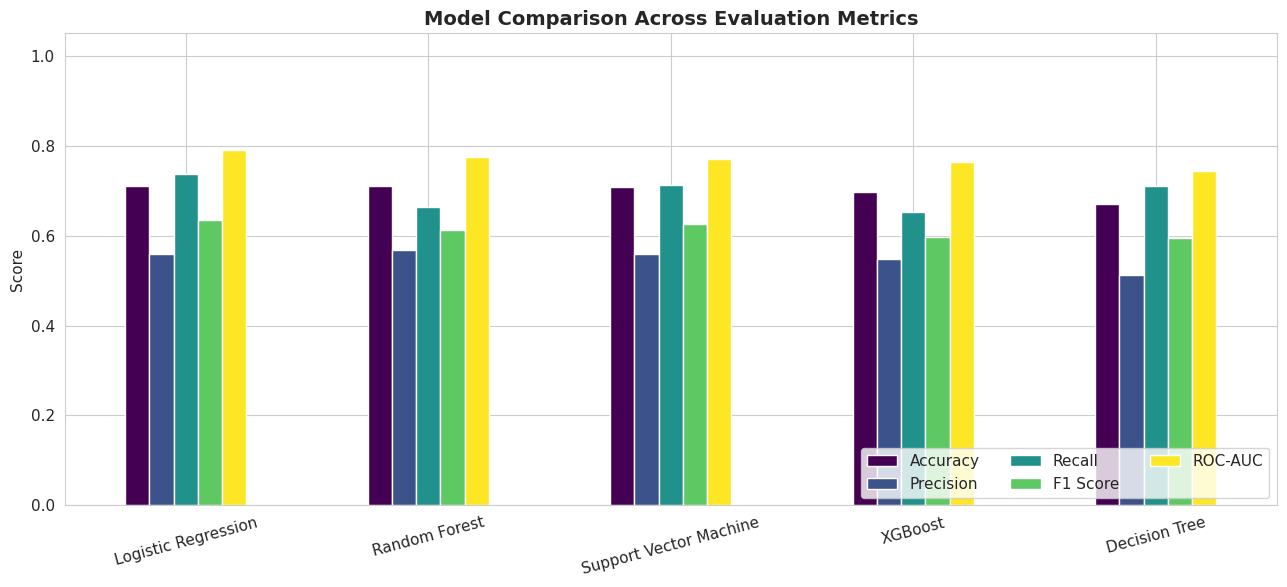

In [38]:
# Visual comparison of all metrics across models
fig, ax = plt.subplots(figsize=(13, 6))
results_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Model Comparison Across Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', ncol=3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../images/11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

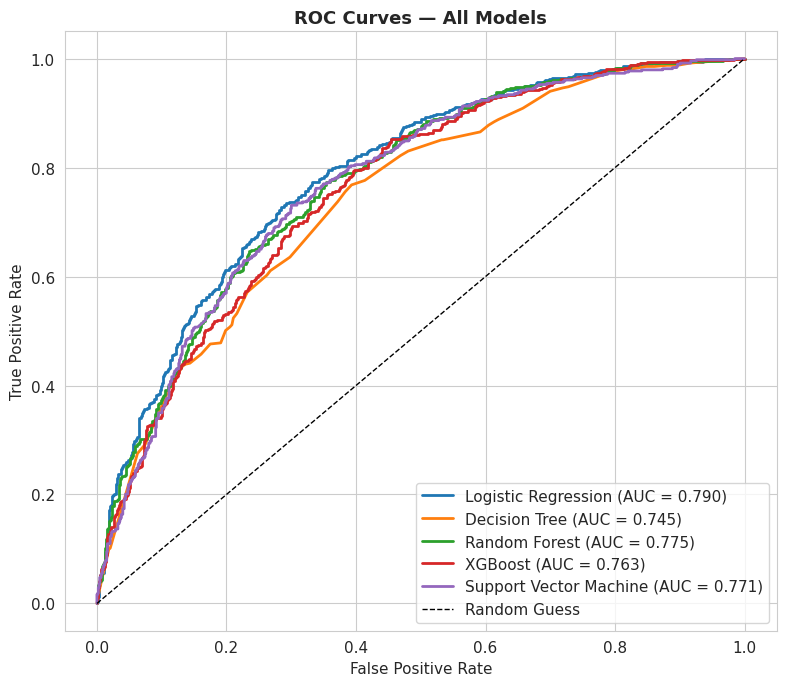

In [39]:
# ROC Curves for all models
fig, ax = plt.subplots(figsize=(8, 7))
test_sets = {
    'Logistic Regression': (X_test_scaled, log_reg),
    'Decision Tree': (X_test, dt),
    'Random Forest': (X_test, rf),
    'XGBoost': (X_test, xgb),
    'Support Vector Machine': (X_test_scaled, svm),
}
for name, (X_te, model) in test_sets.items():
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/12_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

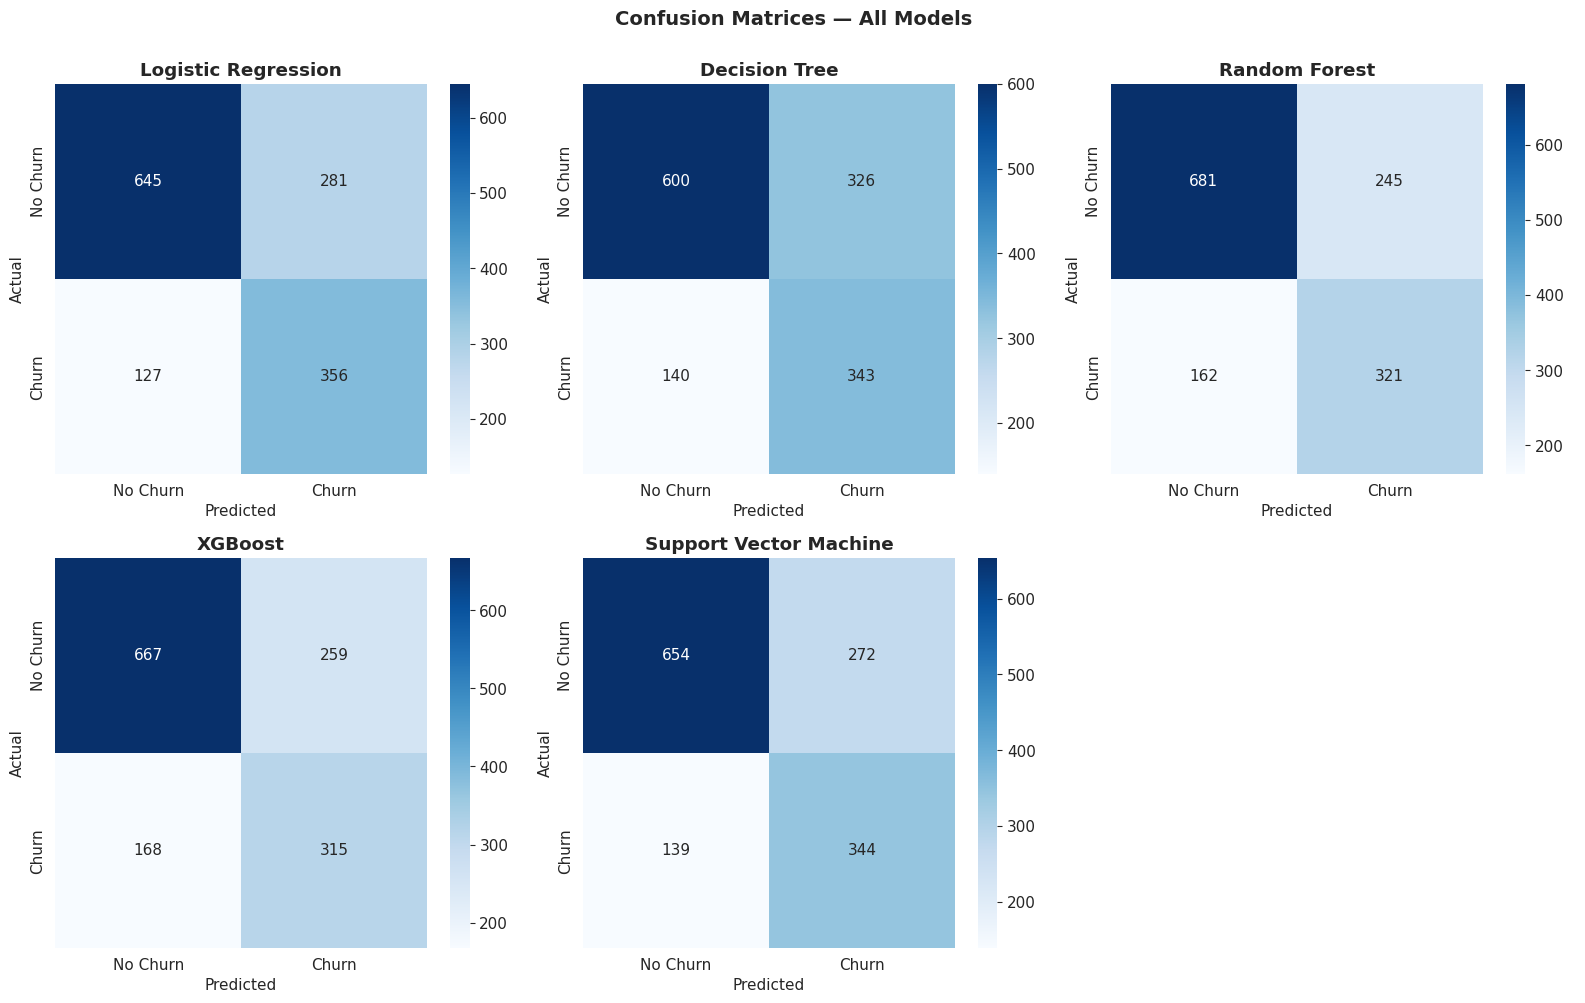

In [40]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, (X_te, model)) in enumerate(test_sets.items()):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('../images/13_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Select best model by ROC-AUC (most robust metric under class imbalance)
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = trained_models[best_model_name]
print(f"BEST MODEL: {best_model_name}")
print(results_df.loc[best_model_name])

BEST MODEL: Logistic Regression
Accuracy     0.7104
Precision    0.5589
Recall       0.7371
F1 Score     0.6357
ROC-AUC      0.7895
Name: Logistic Regression, dtype: float64


---
## 8. Feature Importance Analysis

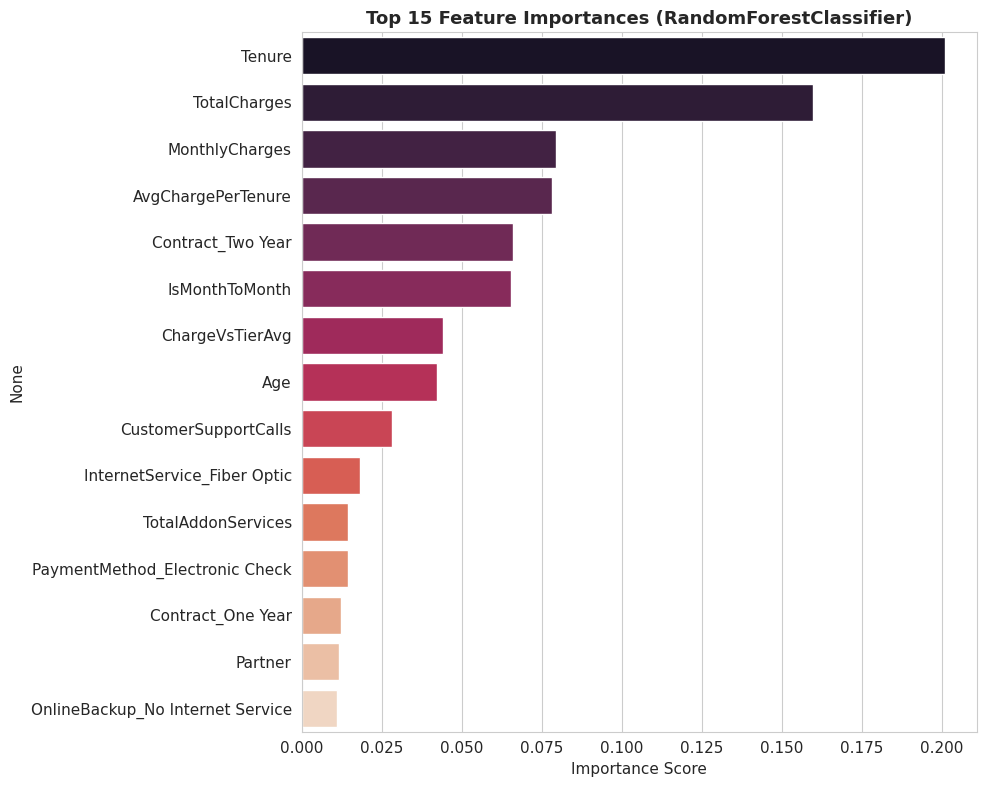

Tenure                              0.201006
TotalCharges                        0.159861
MonthlyCharges                      0.079361
AvgChargePerTenure                  0.078147
Contract_Two Year                   0.066149
IsMonthToMonth                      0.065494
ChargeVsTierAvg                     0.044263
Age                                 0.042404
CustomerSupportCalls                0.028192
InternetService_Fiber Optic         0.018316
TotalAddonServices                  0.014470
PaymentMethod_Electronic Check      0.014406
Contract_One Year                   0.012489
Partner                             0.011633
OnlineBackup_No Internet Service    0.011098
dtype: float64

In [42]:
# Feature importance from the best tree-based model (or fallback to Random Forest for interpretability)
importance_source = best_model if hasattr(best_model, 'feature_importances_') else rf
importances = pd.Series(importance_source.feature_importances_, index=X.columns).sort_values(ascending=False)

top_features = importances.head(15)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index,
            palette='rocket', legend=False, ax=ax)
ax.set_title(f'Top 15 Feature Importances ({importance_source.__class__.__name__})', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top_features

---
## 9. Save Model Artifacts for the Dashboard

In [43]:
import json

# Persist the best model, the scaler, and the exact feature column order
joblib.dump(best_model, '../models/customer_churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_columns.pkl')
joblib.dump(numeric_features, '../models/numeric_features.pkl')

# Also save to project root as requested in the deliverables spec
joblib.dump(best_model, '../customer_churn_model.pkl')

# Save metrics + metadata as JSON for the dashboard to read without retraining
metadata = {
    'best_model_name': best_model_name,
    'metrics': results_df.to_dict('index'),
    'feature_columns': list(X.columns),
    'top_features': top_features.to_dict(),
    'needs_scaling': best_model_name in ['Logistic Regression', 'Support Vector Machine'],
}
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Save the cleaned, feature-engineered dataset for the dashboard to load directly
df_dashboard = df_fe.copy()
df_dashboard.insert(0, 'CustomerID', customer_ids.loc[df_dashboard.index].values)
df_dashboard['Churn'] = df_dashboard['Churn'].map({0: 'No', 1: 'Yes'})
df_dashboard.to_csv('../data/customer_churn_cleaned.csv', index=False)

print("Saved: customer_churn_model.pkl, scaler.pkl, feature_columns.pkl, numeric_features.pkl, model_metadata.json")
print("Saved: customer_churn_cleaned.csv")
print(f"\nFinal selected model: {best_model_name}")

Saved: customer_churn_model.pkl, scaler.pkl, feature_columns.pkl, numeric_features.pkl, model_metadata.json
Saved: customer_churn_cleaned.csv

Final selected model: Logistic Regression


---
## 10. Business Insights & Recommendations

### Why customers leave (key drivers, from EDA + feature importance)
1. **Short-term commitment** — Month-to-month contract customers churn at a far higher rate
   than annual or two-year contract holders. Lack of a commitment mechanism is the single
   biggest churn lever.
2. **Early-lifecycle risk** — Churn is concentrated in the first 6–12 months. New customers
   haven't yet formed a habit or seen enough value to justify staying.
3. **Service friction** — Customers placing 4+ support calls churn at a much higher rate.
   Repeated contact is a strong leading indicator of dissatisfaction.
4. **Price sensitivity at the high end** — Fiber-optic and high-monthly-charge customers
   churn more, suggesting a value perception gap rather than absolute price intolerance.
5. **Payment friction** — Electronic check payers (a manual, non-automatic method) churn
   more than customers on autopay/credit card, who are "stickier" by default.
6. **Low product attachment** — Customers without add-ons like Online Security or Tech
   Support are less embedded in the ecosystem and easier to leave.

### High-risk customer profile
A customer is at elevated churn risk if they have **most** of: a month-to-month contract,
tenure under 12 months, fiber-optic internet, no online security/tech support, electronic
check payment, and 4+ recent support calls.

### Retention recommendations
- **Incentivize contract upgrades**: targeted discounts for month-to-month customers who
  switch to 1- or 2-year contracts, especially during their first 90 days.
- **Onboarding intervention program**: proactive check-ins and value-reinforcement
  communications during months 1–6, the highest-risk window.
- **Support-call triage**: flag any customer on their 3rd support call within 60 days for
  a retention specialist follow-up before a 4th call occurs.
- **Bundle add-ons**: offer free trials of Online Security / Tech Support to fiber and
  high-bill customers to increase product attachment and switching cost.
- **Payment method nudges**: incentivize a switch from electronic check to autopay/credit
  card with a small bill credit.

### Suggested churn-reduction strategy (operational)
1. Score the full customer base weekly with the trained model.
2. Route customers above a chosen risk threshold into a retention workflow, prioritized
   by predicted churn probability **and** customer value (MonthlyCharges × Tenure).
3. A/B test retention offers (discount vs. service upgrade vs. contract incentive) against
   a control group to measure causal impact, not just correlation.
4. Track the model's precision/recall in production monthly and retrain quarterly as
   customer behavior shifts.
